In [1]:
import sys,os
import csv
import logging
import traceback
from collections import Counter
from os.path import join as pjoin
import json

import numpy as np
from Bio import PDB
from Bio.PDB.PDBParser import PDBParser
import pandas as pd

from rna_bits.utils.data_path import get_path
from rna_bits.utils.ss import parse_ss_file
from rna_bits.utils.ss import Segmenter
from rna_bits.utils.misc import remove_string_end
from rna_bits.utils.mc_annotate import query_mc_name, mc_name_to_tuple

from rna_bits.data.benchmark.auto_from_pdb.collect import collect, collect_multi






In [38]:
%config InlineBackend.figure_formats = ['png']


In [2]:
# DIR = ("benchmark/auto_from_pdb/all/info/")
# df = collect(DIR)
# print(df)

DIR = ("benchmark/auto_from_pdb/all/insert_loops_sample_50_exclude_native/measures")
df = collect_multi(DIR)



In [3]:
df

rmsd        pvalue     DI_ALL   INF_ALL  \
name           instance                                                 
NR_4.0_00361.1 1         20.076946  0.000000e+00  26.638224  0.753689   
               10        19.767635  0.000000e+00  27.861148  0.709505   
               11        21.524808  3.275158e-15  30.280796  0.710840   
               12        14.691128  0.000000e+00  20.502552  0.716551   
               13        18.562496  0.000000e+00  26.929755  0.689293   
...                            ...           ...        ...       ...   
NR_4.0_99276.1 50         4.064168  1.027117e-02   6.263303  0.648886   
               6          2.415248  6.138649e-04   3.607870  0.669439   
               7          2.415248  6.138649e-04   3.607870  0.669439   
               8          2.780037  1.223993e-03   3.849282  0.722222   
               9          3.998887  9.322375e-03   6.322796  0.632456   

                           INF_WC   INF_NWC  INF_STACK  \
name           instance                                  
NR_4.0_00361.1 1         0.884678  0.500000   0.705302   
               10        0.872098  0.408248   0.652640   
               11        0.861397  0.158114   0.684737   
               12        0.907079  0.188982   0.660963   
               13        0.883208  0.333333   0.627355   
...                           ...       ...        ...   
NR_4.0_99276.1 50        0.912871 -1.000000   0.560449   
               6         1.000000 -1.000000   0.547723   
               7         1.000000 -1.000000   0.547723   
               8         0.912871 -1.000000   0.666667   
               9         0.912871 -1.000000   0.540062   

                                                                       DIR  \
name           instance                                                      
NR_4.0_00361.1 1         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               10        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               11        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               12        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               13        benchmark/auto_from_pdb/all/insert_loops_sampl...   
...                                                                    ...   
NR_4.0_99276.1 50        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               6         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               7         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               8         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               9         benchmark/auto_from_pdb/all/insert_loops_sampl...   

                                                                  REAL_DIR  
name           instance                                                     
NR_4.0_00361.1 1         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               10        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               11        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               12        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               13        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
...                                                                    ...  
NR_4.0_99276.1 50        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               6         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               7         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               8         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               9         /home/paul/Masters/RNA/data/benchmark/auto_fro...  

[12550 rows x 9 columns]

In [16]:
df.groupby("name").mean()

KeyError: 'name'

In [ ]:
df.groupby("name").min()["rmsd"]

In [ ]:
info = collect("benchmark/auto_from_pdb/all/info/")
info_limited = collect("benchmark/auto_from_pdb/bp2_limited/info/")

s=    (set(info.index) - set(info_limited.index))
[True if i in s else False for i in info.index]
info["has_junctions"] = [True if i in s else False for i in info.index]

def collect_and_add_info(D):
    df = collect_multi(D)
    
    rass_info = collect_multi(pjoin(D,"..", "rass_info"))

    df = (
        info.drop(columns=["DIR", "REAL_DIR"])
        .join(rass_info.drop(columns=["DIR", "REAL_DIR"]))
        .join(df.drop(columns=["DIR", "REAL_DIR"]))
    )
    df["loops_missing"] = df["num_loops"] > df["num_loops_found"]
    return df

singles = {}
singles["from_native"] = collect_and_add_info("benchmark/auto_from_pdb/all/insert_loops_force_native/measures")
singles["loops_top"] = collect_and_add_info("benchmark/auto_from_pdb/all/insert_loops_top_1_exclude_native/measures")

multis =  {}
multis["loops_sample"] = collect_and_add_info("benchmark/auto_from_pdb/all/insert_loops_sample_50_exclude_native/measures")
multis["bp2_reliable"] = collect_and_add_info("benchmark/auto_from_pdb/bp2_limited/bp2_with_ss_reliable/measures")
multis["bp2_all"] = collect_and_add_info("benchmark/auto_from_pdb/bp2_limited/bp2_with_ss_all/measures")


In [ ]:
D= "benchmark/auto_from_pdb/all/insert_loops_sample_50_exclude_native/measures"
rass_info = collect_multi(pjoin(D,"..", "rass_info"))
rass_info

In [ ]:
df = collect_and_add_info(D)

In [ ]:
df[df["loops_missing"]]

In [ ]:
a.groupby("name").min()["rmsd"]

In [ ]:
fn = singles["from_native"]

In [ ]:
set(info.index) - set(fn.reset_index().set_index("name").index)

In [ ]:
# df = pd.DataFrame([[38.0, 2.0, 18.0, 22.0, 21, np.nan],[19, 439, 6, 452, 226,232]],
#                   index=pd.Index(['Tumour (Positive)', 'Non-Tumour (Negative)'], name='Actual Label:'),
#                   columns=pd.MultiIndex.from_product([['Decision Tree', 'Regression', 'Random'],['Tumour', 'Non-Tumour']], names=['Model:', 'Predicted:']))
# df.style

# df.columns

In [17]:
# df = pd.DataFrame([[38.0, 2.0, 18.0],[19, 439, 6]],
#                   index=pd.Index(['Tumour (Positive)', 'Non-Tumour (Negative)'], name='Actual Label:'),
#                   columns=[("adsf", "1"), ("asdf", "2"), "ddd"])
# df.style



In [18]:
info

,pdb_chains,num_nucs,DIR,REAL_DIR,has_junctions
name,,,,,
NR_4.0_00361.1,7LYG|1|A,138,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,48,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,72,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,22,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,46,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,71,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,67,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,74,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [19]:
# df = pd.DataFrame(index = info.index, columns = pd.MultiIndex.from_tuples([], names=["", ""]))
# df[ "", "pdb_chains"] = info["pdb_chains"]

# df[ "", "num_nucs"] = info["num_nucs"]

# for (k,v) in singles.items():
#     df[k, "."] = v.reset_index().set_index(["name"])["rmsd"]
# for (k,v) in multis.items():
#     df[k, "best"] = v["rmsd"].groupby("name").min()
#     df[k, "mean"] = v["rmsd"].groupby("name").mean()
#     df[k, "variance"] = v["rmsd"].groupby("name").var()
# df.sort_values(by=[("","num_nucs")], inplace=True)
# # Remove rows that have all NaN's
# values = list(set(df.columns) - {("", "pdb_chains"), ("", "num_nucs")})
# df.drop(df[df[values].isna().all(axis=1)].index)
# df

In [20]:
def create_table(metric, best_is_min):
    df = pd.DataFrame(index = info.index, columns = pd.MultiIndex.from_tuples([], names=["", ""]))
    df[ "", "pdb_chains"] = info["pdb_chains"]

    df[ "", "num_nucs"] = info["num_nucs"]

    for (k,v) in singles.items():
        df[k, "."] = v.reset_index().set_index(["name"])[metric]
    for (k,v) in multis.items():
        if best_is_min:
            df[k, "best"] = v[metric].groupby("name").min()
        else:
            df[k, "best"] = v[metric].groupby("name").max()

        df[k, "mean"] = v[metric].groupby("name").mean()
        df[k, "variance"] = v[metric].groupby("name").var()
    df.sort_values(by=[("","num_nucs")], inplace=True)
    # Remove rows that have all NaN's
    values = list(set(df.columns) - {("", "pdb_chains"), ("", "num_nucs")})
    df.drop(df[df[values].isna().all(axis=1)].index, inplace=True)
    
    df.style.set_caption("asdfads")

    return df

# def make_pretty(styler):
#     styler.set_caption("RMSD")
#     return styler

# df = create_table("INF_ALL", best_is_min=False)
# df.style

In [21]:
with pd.ExcelWriter('output.xlsx') as writer:  
    df=create_table("rmsd", best_is_min=True)
    df.to_excel(writer, sheet_name='RMSD')
    
    df=create_table("INF_ALL", best_is_min=False)
    df.to_excel(writer, sheet_name='INF')
    
    df=create_table("DI_ALL", best_is_min=True)
    df.to_excel(writer, sheet_name='DI')


In [22]:
values

NameError: name 'values' is not defined

In [ ]:
df.style.to_excel("asdf.xlsx", na_rep="-")

In [23]:
fn["rmsd"].mean()

2.057136822428038

In [24]:
fn["rmsd"].var()

1.5369378363745838

In [25]:
import seaborn as sns

<AxesSubplot: xlabel='rmsd'>

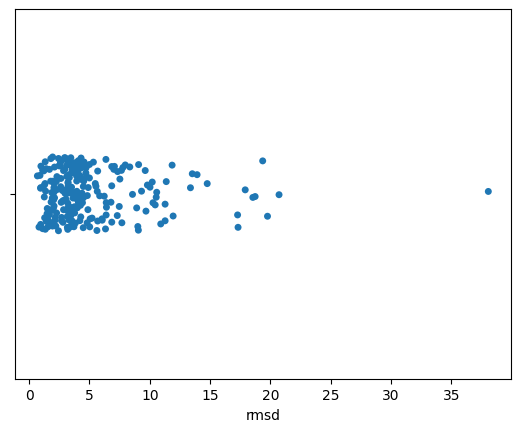

In [39]:
df = singles["loops_top"]
sns.stripplot(x=df[df["loops_missing"]==False]["rmsd"])

<AxesSubplot: xlabel='rmsd'>

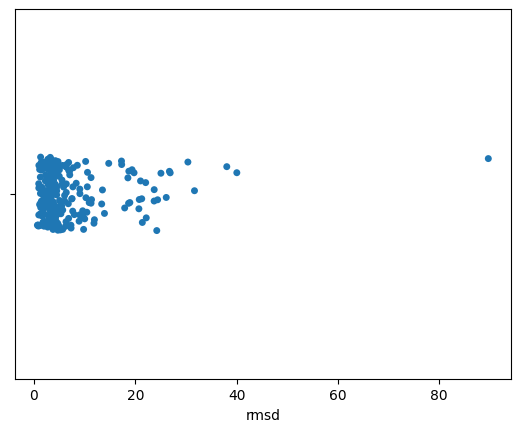

In [27]:
sns.stripplot(x=df["rmsd"])

/home/paul/miniconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot: xlabel='rmsd'>

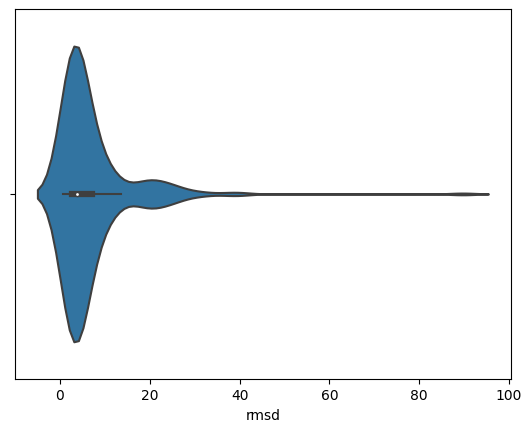

In [28]:
sns.violinplot(singles["loops_top"]["rmsd"])

In [29]:
fn = fn.drop(columns=["DIR", "REAL_DIR"]).join(info.drop(columns=["DIR", "REAL_DIR"]))

KeyError: "['DIR', 'REAL_DIR'] not found in axis"

In [ ]:
sns.scatterplot(x = fn["num_nucs"], y=fn["rmsd"])

<AxesSubplot: title={'center': 'Distribution of molecule sizes'}, xlabel='num_nucs', ylabel='has_junctions'>

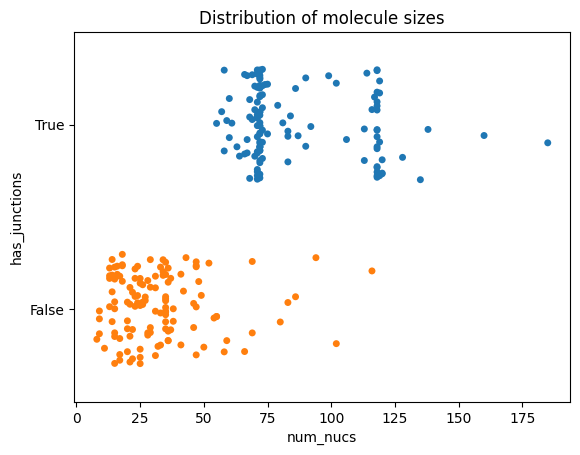

In [72]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )
p = sns.stripplot(     jitter=0.3,        
        data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="has_junctions",
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Distribution of molecule sizes")
p

In [46]:
info

,pdb_chains,num_nucs,DIR,REAL_DIR,has_junctions
name,,,,,
NR_4.0_00361.1,7LYG|1|A,138,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,48,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,72,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,22,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,46,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,71,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,67,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,74,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [97]:
" ".join([a + ".pdb" for a in (info[(116 <= info["num_nucs"]) & (info["num_nucs"] <= 120)].index)])

'NR_4.0_07539.1.pdb NR_4.0_10157.105.pdb NR_4.0_10255.27.pdb NR_4.0_11525.1.pdb NR_4.0_17605.2.pdb NR_4.0_18586.49.pdb NR_4.0_20401.1.pdb NR_4.0_21609.1.pdb NR_4.0_36108.1.pdb NR_4.0_42467.1.pdb NR_4.0_42832.1.pdb NR_4.0_43536.1.pdb NR_4.0_49345.1.pdb NR_4.0_51489.1.pdb NR_4.0_52752.14.pdb NR_4.0_55569.1.pdb NR_4.0_62824.1.pdb NR_4.0_64727.1.pdb NR_4.0_65336.1.pdb NR_4.0_69984.2.pdb NR_4.0_71748.1.pdb NR_4.0_75628.1.pdb NR_4.0_79566.1.pdb NR_4.0_83043.1.pdb NR_4.0_83277.1.pdb NR_4.0_96182.1.pdb'

In [99]:
(info[(116 <= info["num_nucs"]) & (info["num_nucs"] <= 120)])

,pdb_chains,num_nucs,DIR,REAL_DIR,has_junctions
name,,,,,
NR_4.0_07539.1,8EUG|1|9,118,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_10157.105,5J7L|1|DB,119,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_10255.27,7O7Y|1|B7,118,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_11525.1,7R81|1|B1,119,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_17605.2,3J79|1|B,116,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_18586.49,5TBW|1|AS,120,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_20401.1,7QCA|1|L70,118,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_21609.1,7CPU|1|L7,118,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_36108.1,7OLC|1|3,119,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


name
NR_4.0_00361.1    False
NR_4.0_00810.1     True
NR_4.0_01147.1     True
NR_4.0_01689.1     True
NR_4.0_01806.1     True
                  ...  
NR_4.0_96274.1     True
NR_4.0_97773.1     True
NR_4.0_98593.1     True
NR_4.0_98802.1     True
NR_4.0_99276.1     True
Name: num_nucs, Length: 251, dtype: bool

In [79]:

import pandas as pd
import plotly.express as px
import numpy as np



p = px.strip(     #jitter=0.3,        
        data_frame = info.reset_index().replace({"has_junctions": {False: "False", True: "True"}}),
        x="num_nucs",  y="has_junctions", hover_name = "name", hover_data=["name", "pdb_chains"],
            # range_y = (-0.1, 1.1),
        height = 1500
             )
p

In [56]:
info.replace({"has_junctions": {False: "False", True: "True"}})

,pdb_chains,num_nucs,DIR,REAL_DIR,has_junctions
name,,,,,
NR_4.0_00361.1,7LYG|1|A,138,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,48,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,72,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,22,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,46,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,71,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,67,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,74,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [195]:
fn

,,pdb_chains,num_nucs,has_junctions,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK
name,instance,,,,,,,,,,
NR_4.0_00361.1,1,7LYG|1|A,138,True,3.354979,0.000000e+00,3.635884,0.922741,0.988826,0.670820,0.903696
NR_4.0_00810.1,1,4C7O|1|E,48,False,3.259122,0.000000e+00,3.530586,0.923111,1.000000,1.000000,0.880078
NR_4.0_01147.1,1,6GZ4|1|Bw,72,True,1.596263,0.000000e+00,1.797885,0.887856,0.977008,0.516398,0.880391
NR_4.0_01689.1,1,6KYV|1|G,22,False,1.166121,4.247957e-07,1.235868,0.943564,1.000000,1.000000,0.909509
NR_4.0_01806.1,1,3IAB|1|R,46,False,1.334821,0.000000e+00,1.415719,0.942857,1.000000,-1.000000,0.913043
...,...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,1,6T4Q|1|7,71,True,1.650925,0.000000e+00,1.802863,0.915724,0.974679,0.857143,0.902698
NR_4.0_97773.1,1,6YDP|1|AV,67,True,2.051232,0.000000e+00,2.183570,0.939394,1.000000,0.500000,0.928571
NR_4.0_98593.1,1,5D8H|1|A,74,True,1.252860,0.000000e+00,1.327057,0.944089,0.974679,0.894427,0.941858


In [ ]:
values = list(set(df.columns) - {"pdb_chains", "num_nucs"})
df[df[values].isna().any(axis=1)]

In [58]:
to_concat = []
methods = []
for k,v in singles.items():
    to_concat.append(v.assign(method=k).assign(multi=False))
    methods.append(k)
for k,v in multis.items():
    to_concat.append(v.assign(method=k).assign(multi=True))
    methods.append(k)

all_data = pd.concat(to_concat).reset_index().set_index([ "name", "method", "instance"])
all_data

pdb_chains  num_nucs  has_junctions  \
name           method      instance                                       
NR_4.0_00361.1 from_native 1          7LYG|1|A       138           True   
NR_4.0_00810.1 from_native 1          4C7O|1|E        48          False   
NR_4.0_01147.1 from_native 1         6GZ4|1|Bw        72           True   
NR_4.0_01689.1 from_native 1          6KYV|1|G        22          False   
NR_4.0_01806.1 from_native 1          3IAB|1|R        46          False   
...                                        ...       ...            ...   
NR_4.0_99276.1 bp2_all     out_0_5    7ONB|1|H        18          False   
                           out_0_6    7ONB|1|H        18          False   
                           out_0_7    7ONB|1|H        18          False   
                           out_0_8    7ONB|1|H        18          False   
                           out_0_9    7ONB|1|H        18          False   

                                         rmsd        pvalue    DI_ALL  \
name           method      instance                                     
NR_4.0_00361.1 from_native 1         3.354979  0.000000e+00  3.635884   
NR_4.0_00810.1 from_native 1         3.259122  0.000000e+00  3.530586   
NR_4.0_01147.1 from_native 1         1.596263  0.000000e+00  1.797885   
NR_4.0_01689.1 from_native 1         1.166121  4.247957e-07  1.235868   
NR_4.0_01806.1 from_native 1         1.334821  0.000000e+00  1.415719   
...                                       ...           ...       ...   
NR_4.0_99276.1 bp2_all     out_0_5   4.640882  2.297268e-02  5.721664   
                           out_0_6   4.773072  2.727420e-02  6.535798   
                           out_0_7   4.342802  1.532856e-02  7.369979   
                           out_0_8   3.427559  3.792974e-03  4.612138   
                           out_0_9   4.773072  2.727420e-02  6.535798   

                                      INF_ALL    INF_WC   INF_NWC  INF_STACK  \
name           method      instance                                            
NR_4.0_00361.1 from_native 1         0.922741  0.988826  0.670820   0.903696   
NR_4.0_00810.1 from_native 1         0.923111  1.000000  1.000000   0.880078   
NR_4.0_01147.1 from_native 1         0.887856  0.977008  0.516398   0.880391   
NR_4.0_01689.1 from_native 1         0.943564  1.000000  1.000000   0.909509   
NR_4.0_01806.1 from_native 1         0.942857  1.000000 -1.000000   0.913043   
...                                       ...       ...       ...        ...   
NR_4.0_99276.1 bp2_all     out_0_5   0.811107  1.000000 -1.000000   0.771517   
                           out_0_6   0.730297  1.000000 -1.000000   0.639010   
                           out_0_7   0.589256  0.912871 -1.000000   0.456435   
                           out_0_8   0.743161  1.000000 -1.000000   0.666667   
                           out_0_9   0.730297  1.000000 -1.000000   0.639010   

                                     multi  
name           method      instance         
NR_4.0_00361.1 from_native 1         False  
NR_4.0_00810.1 from_native 1         False  
NR_4.0_01147.1 from_native 1         False  
NR_4.0_01689.1 from_native 1         False  
NR_4.0_01806.1 from_native 1         False  
...                                    ...  
NR_4.0_99276.1 bp2_all     out_0_5    True  
                           out_0_6    True  
                           out_0_7    True  
                           out_0_8    True  
                           out_0_9    True  

[25752 rows x 11 columns]

In [ ]:
all_data.loc[("NR_4.0_00361.1", "1")]

In [ ]:
all_data

In [ ]:
sns.stripplot(jitter=0.4, data = all_data["num_nucs"].groupby(["name", "method"]).mean().reset_index(), x = "method", y = "num_nucs")



In [ ]:
all_data[all_data["rmsd"].isna()]

In [62]:
all_data[all_data["num_nucs"] >= 20]

pdb_chains  num_nucs  has_junctions  \
name           method      instance                                       
NR_4.0_00361.1 from_native 1          7LYG|1|A       138           True   
NR_4.0_00810.1 from_native 1          4C7O|1|E        48          False   
NR_4.0_01147.1 from_native 1         6GZ4|1|Bw        72           True   
NR_4.0_01689.1 from_native 1          6KYV|1|G        22          False   
NR_4.0_01806.1 from_native 1          3IAB|1|R        46          False   
...                                        ...       ...            ...   
NR_4.0_95874.1 bp2_all     out_0_5    3R9X|1|C        24          False   
                           out_0_6    3R9X|1|C        24          False   
                           out_0_7    3R9X|1|C        24          False   
                           out_0_8    3R9X|1|C        24          False   
                           out_0_9    3R9X|1|C        24          False   

                                         rmsd        pvalue    DI_ALL  \
name           method      instance                                     
NR_4.0_00361.1 from_native 1         3.354979  0.000000e+00  3.635884   
NR_4.0_00810.1 from_native 1         3.259122  0.000000e+00  3.530586   
NR_4.0_01147.1 from_native 1         1.596263  0.000000e+00  1.797885   
NR_4.0_01689.1 from_native 1         1.166121  4.247957e-07  1.235868   
NR_4.0_01806.1 from_native 1         1.334821  0.000000e+00  1.415719   
...                                       ...           ...       ...   
NR_4.0_95874.1 bp2_all     out_0_5   0.674092  7.766847e-09  0.725482   
                           out_0_6   3.923807  5.901918e-05  4.947409   
                           out_0_7   4.974973  5.450376e-04  6.629066   
                           out_0_8   4.974973  5.450376e-04  6.629066   
                           out_0_9   3.874118  5.270925e-05  5.256923   

                                      INF_ALL    INF_WC   INF_NWC  INF_STACK  \
name           method      instance                                            
NR_4.0_00361.1 from_native 1         0.922741  0.988826  0.670820   0.903696   
NR_4.0_00810.1 from_native 1         0.923111  1.000000  1.000000   0.880078   
NR_4.0_01147.1 from_native 1         0.887856  0.977008  0.516398   0.880391   
NR_4.0_01689.1 from_native 1         0.943564  1.000000  1.000000   0.909509   
NR_4.0_01806.1 from_native 1         0.942857  1.000000 -1.000000   0.913043   
...                                       ...       ...       ...        ...   
NR_4.0_95874.1 bp2_all     out_0_5   0.929164  1.000000  1.000000   0.890264   
                           out_0_6   0.793103  0.942809 -1.000000   0.750939   
                           out_0_7   0.750479  0.942809 -1.000000   0.684211   
                           out_0_8   0.750479  0.942809 -1.000000   0.684211   
                           out_0_9   0.736956  0.942809  0.000000   0.684211   

                                     multi  
name           method      instance         
NR_4.0_00361.1 from_native 1         False  
NR_4.0_00810.1 from_native 1         False  
NR_4.0_01147.1 from_native 1         False  
NR_4.0_01689.1 from_native 1         False  
NR_4.0_01806.1 from_native 1         False  
...                                    ...  
NR_4.0_95874.1 bp2_all     out_0_5    True  
                           out_0_6    True  
                           out_0_7    True  
                           out_0_8    True  
                           out_0_9    True  

[21040 rows x 11 columns]

In [68]:
# # calculate mean and variance of all molecules
# df = all_data
# df = df[df["num_nucs"] >= 20]
# df = df[df["rmsd"].isna() == False]

pdb_chains  num_nucs  has_junctions  \
name           method      instance                                       
NR_4.0_00361.1 from_native 1          7LYG|1|A       138           True   
NR_4.0_00810.1 from_native 1          4C7O|1|E        48          False   
NR_4.0_01147.1 from_native 1         6GZ4|1|Bw        72           True   
NR_4.0_01689.1 from_native 1          6KYV|1|G        22          False   
NR_4.0_01806.1 from_native 1          3IAB|1|R        46          False   
...                                        ...       ...            ...   
NR_4.0_95874.1 bp2_all     out_0_5    3R9X|1|C        24          False   
                           out_0_6    3R9X|1|C        24          False   
                           out_0_7    3R9X|1|C        24          False   
                           out_0_8    3R9X|1|C        24          False   
                           out_0_9    3R9X|1|C        24          False   

                                         rmsd        pvalue    DI_ALL  \
name           method      instance                                     
NR_4.0_00361.1 from_native 1         3.354979  0.000000e+00  3.635884   
NR_4.0_00810.1 from_native 1         3.259122  0.000000e+00  3.530586   
NR_4.0_01147.1 from_native 1         1.596263  0.000000e+00  1.797885   
NR_4.0_01689.1 from_native 1         1.166121  4.247957e-07  1.235868   
NR_4.0_01806.1 from_native 1         1.334821  0.000000e+00  1.415719   
...                                       ...           ...       ...   
NR_4.0_95874.1 bp2_all     out_0_5   0.674092  7.766847e-09  0.725482   
                           out_0_6   3.923807  5.901918e-05  4.947409   
                           out_0_7   4.974973  5.450376e-04  6.629066   
                           out_0_8   4.974973  5.450376e-04  6.629066   
                           out_0_9   3.874118  5.270925e-05  5.256923   

                                      INF_ALL    INF_WC   INF_NWC  INF_STACK  \
name           method      instance                                            
NR_4.0_00361.1 from_native 1         0.922741  0.988826  0.670820   0.903696   
NR_4.0_00810.1 from_native 1         0.923111  1.000000  1.000000   0.880078   
NR_4.0_01147.1 from_native 1         0.887856  0.977008  0.516398   0.880391   
NR_4.0_01689.1 from_native 1         0.943564  1.000000  1.000000   0.909509   
NR_4.0_01806.1 from_native 1         0.942857  1.000000 -1.000000   0.913043   
...                                       ...       ...       ...        ...   
NR_4.0_95874.1 bp2_all     out_0_5   0.929164  1.000000  1.000000   0.890264   
                           out_0_6   0.793103  0.942809 -1.000000   0.750939   
                           out_0_7   0.750479  0.942809 -1.000000   0.684211   
                           out_0_8   0.750479  0.942809 -1.000000   0.684211   
                           out_0_9   0.736956  0.942809  0.000000   0.684211   

                                     multi  
name           method      instance         
NR_4.0_00361.1 from_native 1         False  
NR_4.0_00810.1 from_native 1         False  
NR_4.0_01147.1 from_native 1         False  
NR_4.0_01689.1 from_native 1         False  
NR_4.0_01806.1 from_native 1         False  
...                                    ...  
NR_4.0_95874.1 bp2_all     out_0_5    True  
                           out_0_6    True  
                           out_0_7    True  
                           out_0_8    True  
                           out_0_9    True  

[21040 rows x 11 columns]

In [155]:
df = all_data
no_junctions = list(set([a[0] for a in (df[df["has_junctions"] == False].index)]))

In [156]:
no_junctions

['NR_4.0_40597.1',
 'NR_4.0_49782.1',
 'NR_4.0_02491.1',
 'NR_4.0_83665.1',
 'NR_4.0_51124.1',
 'NR_4.0_94113.1',
 'NR_4.0_95596.1',
 'NR_4.0_00810.1',
 'NR_4.0_52315.1',
 'NR_4.0_26836.2',
 'NR_4.0_24985.1',
 'NR_4.0_80360.2',
 'NR_4.0_67726.2',
 'NR_4.0_99276.1',
 'NR_4.0_69759.1',
 'NR_4.0_21945.1',
 'NR_4.0_23975.1',
 'NR_4.0_17333.1',
 'NR_4.0_90603.1',
 'NR_4.0_65533.1',
 'NR_4.0_14947.1',
 'NR_4.0_73108.1',
 'NR_4.0_66418.1',
 'NR_4.0_91105.1',
 'NR_4.0_26582.1',
 'NR_4.0_52535.1',
 'NR_4.0_07004.1',
 'NR_4.0_08239.1',
 'NR_4.0_57646.1',
 'NR_4.0_44743.1',
 'NR_4.0_83043.1',
 'NR_4.0_74379.1',
 'NR_4.0_75028.1',
 'NR_4.0_01689.1',
 'NR_4.0_51487.1',
 'NR_4.0_23835.1',
 'NR_4.0_39792.1',
 'NR_4.0_23939.1',
 'NR_4.0_72481.1',
 'NR_4.0_31286.1',
 'NR_4.0_32738.1',
 'NR_4.0_53827.1',
 'NR_4.0_53294.1',
 'NR_4.0_04852.2',
 'NR_4.0_70098.1',
 'NR_4.0_16758.1',
 'NR_4.0_95171.1',
 'NR_4.0_81641.1',
 'NR_4.0_10362.1',
 'NR_4.0_26209.1',
 'NR_4.0_51660.3',
 'NR_4.0_22747.1',
 'NR_4.0_526

In [159]:
data_noj = all_data.loc[no_junctions]

In [91]:
data_noj["rmsd"].groupby(["method"]).mean()

method
bp2_all          9.578867
bp2_reliable    12.496497
from_native      1.555770
loops_sample     7.199683
loops_top        5.579571
Name: rmsd, dtype: float64

In [93]:
data_noj["rmsd"].groupby(["method"]).var()

method
bp2_all         118.081461
bp2_reliable    128.958836
from_native       0.701516
loops_sample     91.608078
loops_top        90.825882
Name: rmsd, dtype: float64

In [103]:
no_bp = ["from_native", "loops_top", "loops_sample"]
data_j = all_data.reset_index().set_index("method").loc[no_bp].reset_index().set_index(["name", "method", "instance"])

In [104]:
data_j["rmsd"].groupby(["method"]).mean()

method
from_native     2.057137
loops_sample    8.097697
loops_top       6.870218
Name: rmsd, dtype: float64

In [106]:
data_j["rmsd"].groupby(["method"]).var()

method
from_native      1.536938
loops_sample    74.503131
loops_top       74.384818
Name: rmsd, dtype: float64

In [162]:
def over_all(data):
    df = pd.DataFrame()
    dd = data[data["num_nucs"] < 20]
    for measure in ["rmsd", "INF_ALL", "DI_ALL"]:
        df[measure +"_mean"] = dd[measure].groupby(["method"]).mean()
        df[measure + "_var"] = dd[measure].groupby(["method"]).var()
    dflt = df
    df = pd.DataFrame()
    dd = data[data["num_nucs"] >= 20]
    for measure in ["rmsd", "INF_ALL", "DI_ALL"]:
        df[measure +"_mean"] = dd[measure].groupby(["method"]).mean()
        df[measure + "_var"] = dd[measure].groupby(["method"]).var()
    dfge = df
    return pd.concat([dflt.assign(size="<20"), dfge.assign(size=">=20")]).reset_index().set_index(["size", "method"]) 

In [163]:
over_all(data_noj)  # Means over the dataset that has no junction

rmsd_mean    rmsd_var  INF_ALL_mean  INF_ALL_var  \
size method                                                           
<20  bp2_all        4.087165    3.654663      0.757032     0.012050   
     bp2_reliable   4.040271    3.076777      0.783993     0.008637   
     from_native    0.901799    0.098478      0.937412     0.001738   
     loops_sample   3.728319    4.853984      0.789616     0.012160   
     loops_top      2.640916    3.194002      0.828372     0.012219   
>=20 bp2_all        9.578867  118.081461      0.745166     0.020316   
     bp2_reliable  12.496497  128.958836      0.713621     0.020865   
     from_native    1.555770    0.701516      0.948323     0.000762   
     loops_sample   7.199683   91.608078      0.769697     0.019210   
     loops_top      5.579571   90.825882      0.738657     0.150452   

                   DI_ALL_mean    DI_ALL_var  
size method                                   
<20  bp2_all          5.760914     11.096196  
     bp2_reliable     5.386865      7.738186  
     from_native      0.971263      0.129796  
     loops_sample     5.155899     14.305264  
     loops_top        3.546629      9.297225  
>=20 bp2_all         24.072710  10378.775683  
     bp2_reliable    29.019782  10326.851190  
     from_native      1.651411      0.825503  
     loops_sample    19.502594  10270.636975  
     loops_top       16.440425  10427.986727

In [164]:
over_all(data_j)  # Means over the whole dataset

rmsd_mean   rmsd_var  INF_ALL_mean  INF_ALL_var  \
size method                                                          
<20  from_native    0.901799   0.098478      0.937412     0.001738   
     loops_sample   3.728319   4.853984      0.789616     0.012160   
     loops_top      2.640916   3.194002      0.828372     0.012219   
>=20 from_native    2.219934   1.525436      0.931740     0.001169   
     loops_sample   8.713382  81.249154      0.776557     0.011853   
     loops_top      7.466165  81.587919      0.739115     0.125754   

                   DI_ALL_mean   DI_ALL_var  
size method                                  
<20  from_native      0.971263     0.129796  
     loops_sample     5.155899    14.305264  
     loops_top        3.546629     9.297225  
>=20 from_native      2.388966     1.724892  
     loops_sample    16.066420  4581.023446  
     loops_top       13.667842  4623.747834

In [133]:
data_j

pdb_chains  num_nucs  has_junctions  \
name           method       instance                                       
NR_4.0_00361.1 from_native  1          7LYG|1|A       138           True   
NR_4.0_00810.1 from_native  1          4C7O|1|E        48          False   
NR_4.0_01147.1 from_native  1         6GZ4|1|Bw        72           True   
NR_4.0_01689.1 from_native  1          6KYV|1|G        22          False   
NR_4.0_01806.1 from_native  1          3IAB|1|R        46          False   
...                                         ...       ...            ...   
NR_4.0_99276.1 loops_sample 50         7ONB|1|H        18          False   
                            6          7ONB|1|H        18          False   
                            7          7ONB|1|H        18          False   
                            8          7ONB|1|H        18          False   
                            9          7ONB|1|H        18          False   

                                          rmsd        pvalue    DI_ALL  \
name           method       instance                                     
NR_4.0_00361.1 from_native  1         3.354979  0.000000e+00  3.635884   
NR_4.0_00810.1 from_native  1         3.259122  0.000000e+00  3.530586   
NR_4.0_01147.1 from_native  1         1.596263  0.000000e+00  1.797885   
NR_4.0_01689.1 from_native  1         1.166121  4.247957e-07  1.235868   
NR_4.0_01806.1 from_native  1         1.334821  0.000000e+00  1.415719   
...                                        ...           ...       ...   
NR_4.0_99276.1 loops_sample 50        4.064168  1.027117e-02  6.263303   
                            6         2.415248  6.138649e-04  3.607870   
                            7         2.415248  6.138649e-04  3.607870   
                            8         2.780037  1.223993e-03  3.849282   
                            9         3.998887  9.322375e-03  6.322796   

                                       INF_ALL    INF_WC   INF_NWC  INF_STACK  \
name           method       instance                                            
NR_4.0_00361.1 from_native  1         0.922741  0.988826  0.670820   0.903696   
NR_4.0_00810.1 from_native  1         0.923111  1.000000  1.000000   0.880078   
NR_4.0_01147.1 from_native  1         0.887856  0.977008  0.516398   0.880391   
NR_4.0_01689.1 from_native  1         0.943564  1.000000  1.000000   0.909509   
NR_4.0_01806.1 from_native  1         0.942857  1.000000 -1.000000   0.913043   
...                                        ...       ...       ...        ...   
NR_4.0_99276.1 loops_sample 50        0.648886  0.912871 -1.000000   0.560449   
                            6         0.669439  1.000000 -1.000000   0.547723   
                            7         0.669439  1.000000 -1.000000   0.547723   
                            8         0.722222  0.912871 -1.000000   0.666667   
                            9         0.632456  0.912871 -1.000000   0.540062   

                                      multi  
name           method       instance         
NR_4.0_00361.1 from_native  1         False  
NR_4.0_00810.1 from_native  1         False  
NR_4.0_01147.1 from_native  1         False  
NR_4.0_01689.1 from_native  1         False  
NR_4.0_01806.1 from_native  1         False  
...                                     ...  
NR_4.0_99276.1 loops_sample 50         True  
                            6          True  
                            7          True  
                            8          True  
                            9          True  

[13052 rows x 11 columns]